# Köppen-Geiger climate classification for the catchment
This notebook analyses the Köppen-Geiger climate classification of the catchment region defined in `settings.json`. It uses the catchment shapefile to mask the global Köppen-Geiger raster and shows the dominant climate class(es) present in the region.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import sys
import json
from pathlib import Path
import pandas as pd

from rich import print

In [2]:
# Import koppen_geiger from scripts — works both on SRC and HPC
try:
    from scripts.koppen_geiger import (
        analyse_koppen_geiger,
        KOPPEN_DESCRIPTION,
    )
except ImportError:
    project_root = Path().resolve().parent
    sys.path.append(str(project_root))
    from scripts.koppen_geiger import (
        analyse_koppen_geiger,
        KOPPEN_DESCRIPTION,
    )

In [3]:
# Parameters — overridden by papermill when running on HPC
settings_path = "settings.json"

In [4]:
# Parameters
settings_path = "regions/canada/hysets_01AD003/settings.json"


In [5]:
# Load settings
with open(settings_path, "r") as f:
    settings = json.load(f)

display(settings)

{'caravan_id': 'hysets_01AD003',
 'country': 'canada',
 'calibration_start_date': '1994-08-01T00:00:00Z',
 'calibration_end_date': '2004-07-31T00:00:00Z',
 'validation_start_date': '2004-08-01T00:00:00Z',
 'validation_end_date': '2014-07-31T00:00:00Z',
 'future_start_date': '2029-08-01T00:00:00Z',
 'future_end_date': '2049-08-31T00:00:00Z',
 'CMIP_info': {'dataset': ['MPI-ESM1-2-LR'],
  'ensembles': ['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1'],
  'experiments': ['historical', 'ssp126', 'ssp245', 'ssp370', 'ssp585'],
  'project': 'CMIP6',
  'grid': 'gn'},
 'koppen_raster_path': '/home/ewater-mmelotto/koppen_geiger/1991_2020/koppen_geiger_0p00833333.tif',
 'base_path': '/project/ewater/Data/ewatercycleClimateImpact/HBV',
 'path_caravan': '/project/ewater/Data/ewatercycleClimateImpact/HBV/forcing_data/canada/hysets_01AD003/caravan',
 'path_ERA5': '/project/ewater/Data/ewatercycleClimateImpact/HBV/forcing_data/canada/hysets_01AD003/ERA5',
 'path_DestinE': '/project/ewater/Data/ewatercycleClimateIm

In [6]:
# Build shapefile dict for the catchment
shapefiles = {
    settings["caravan_id"]: {
        "path": settings["path_shape"],
        "edgecolor": "red",
        "linewidth": 1.5,
    }
}

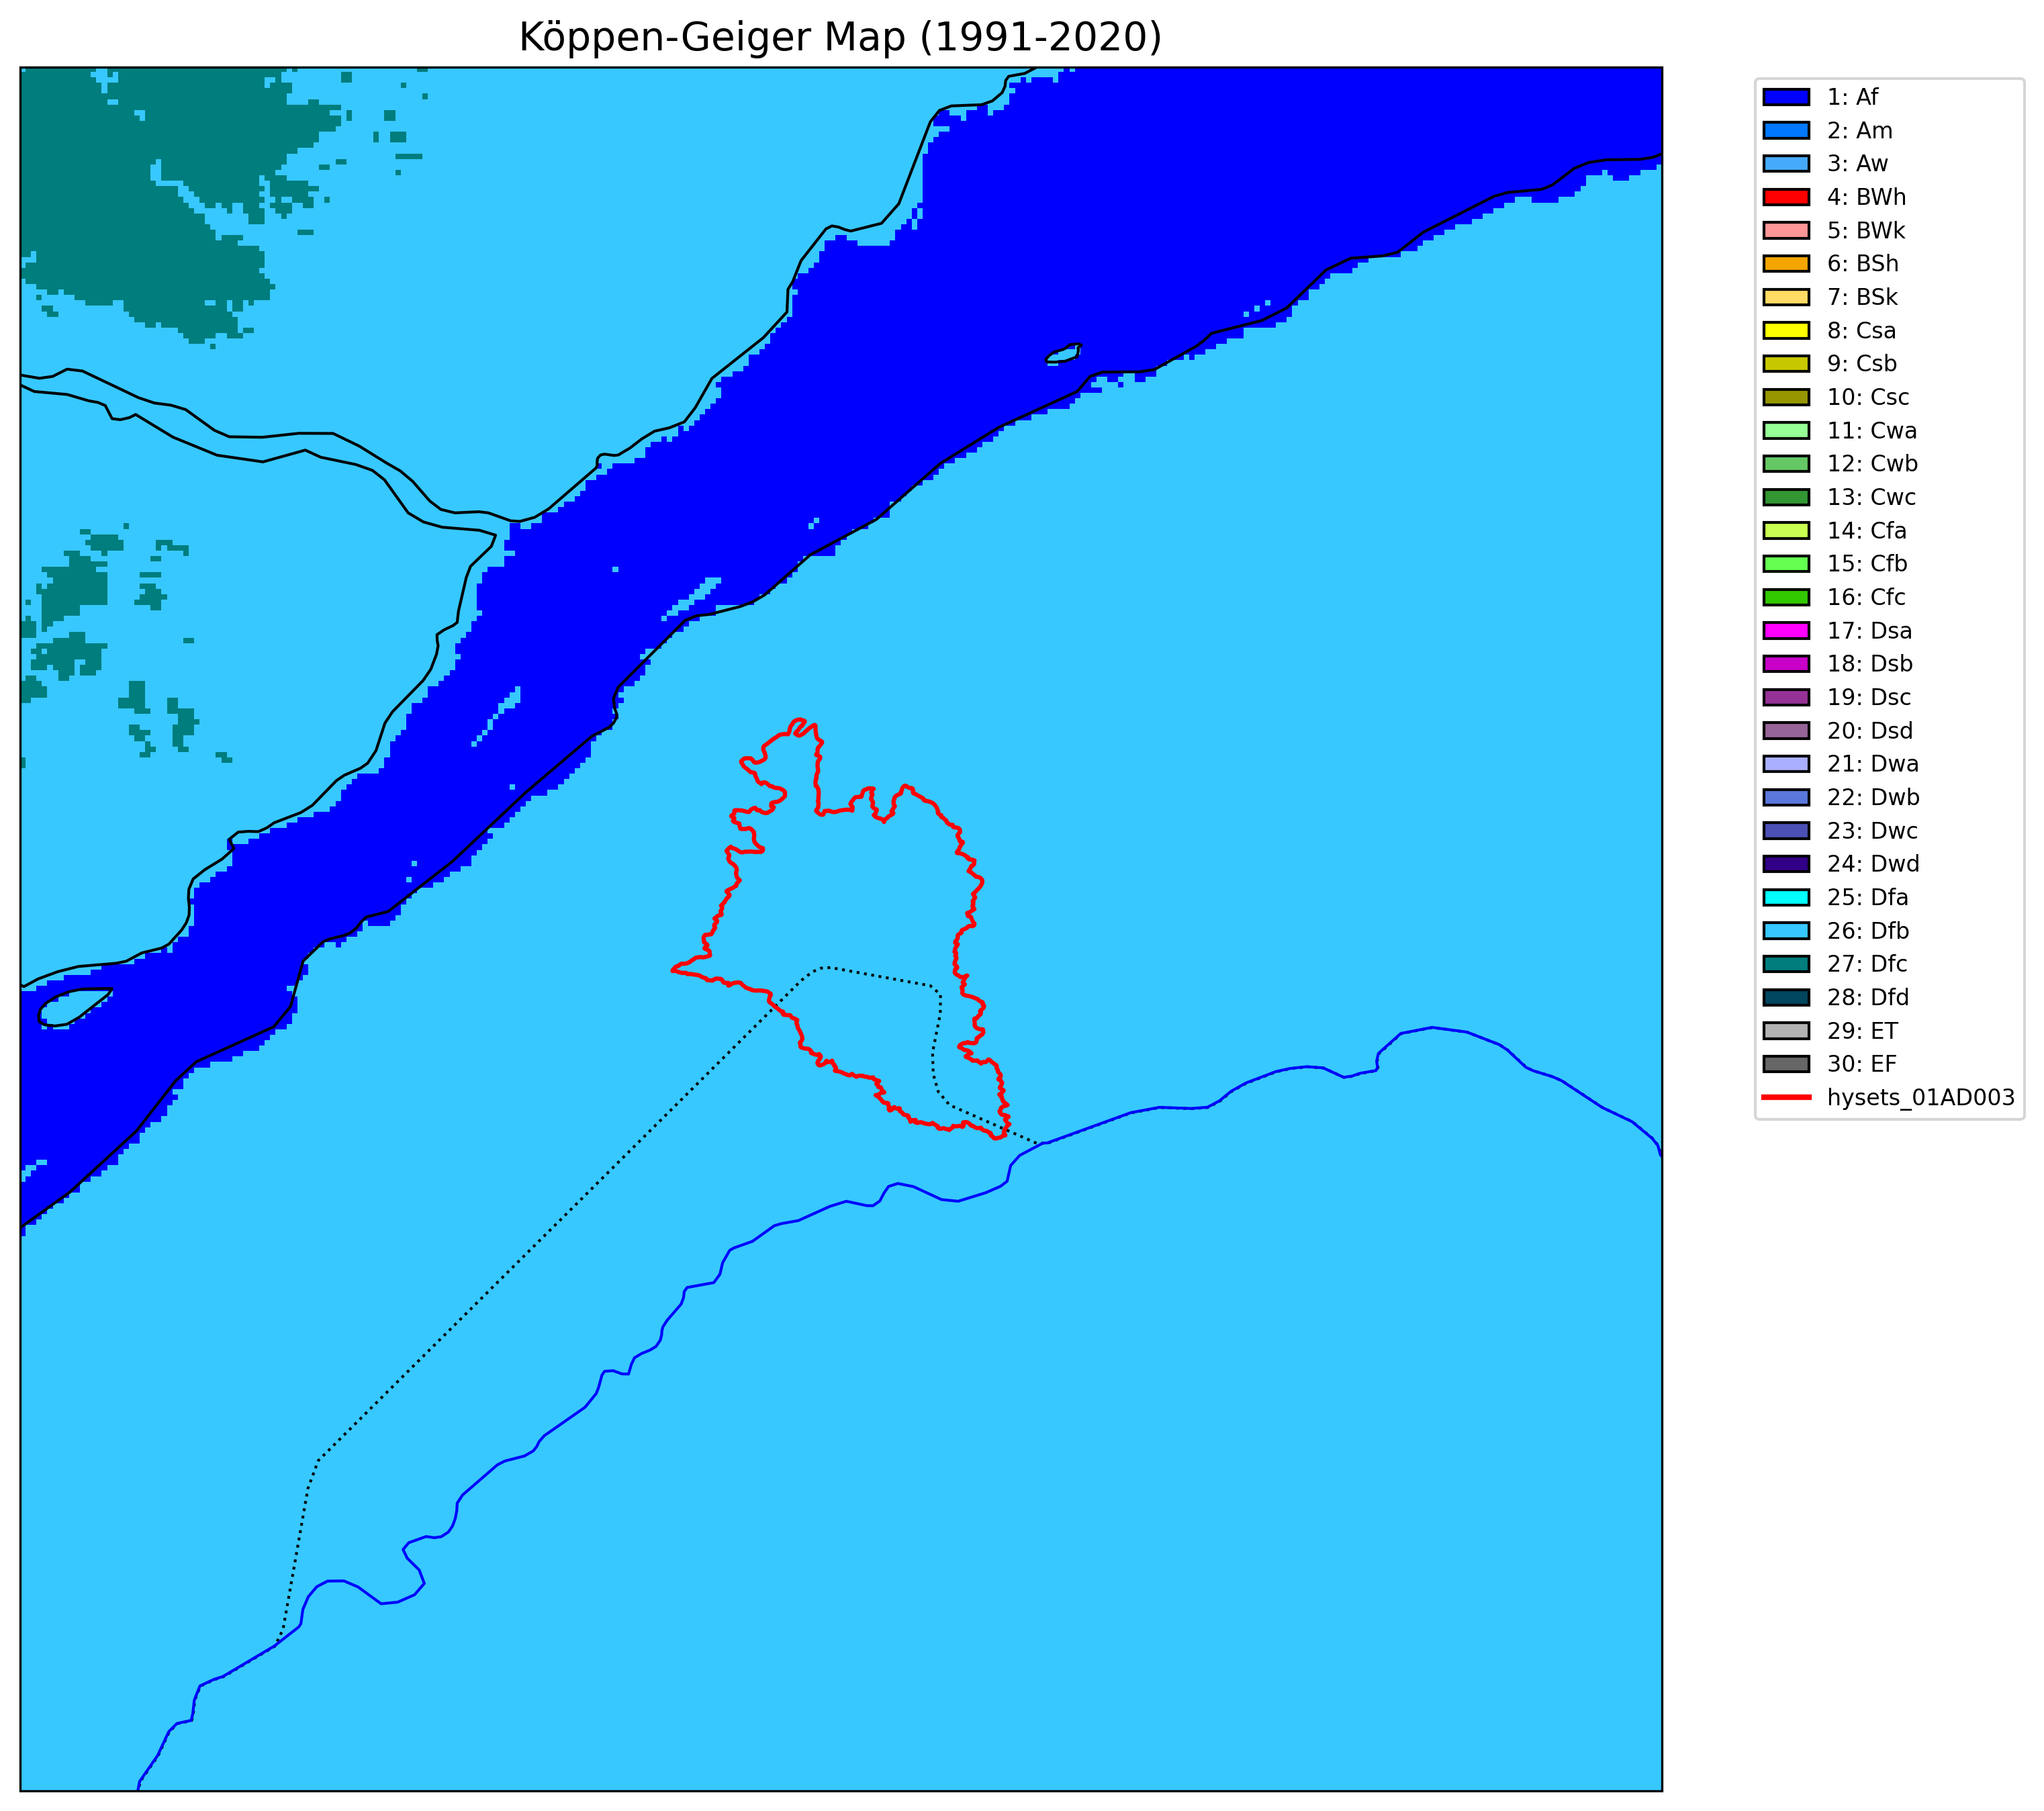

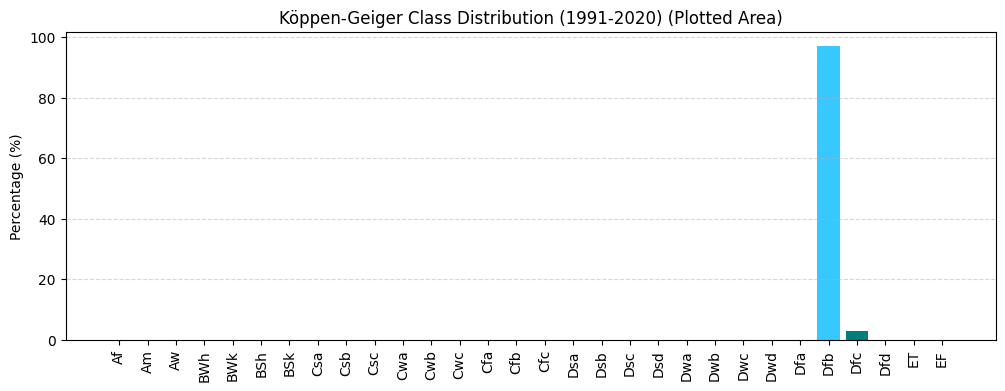

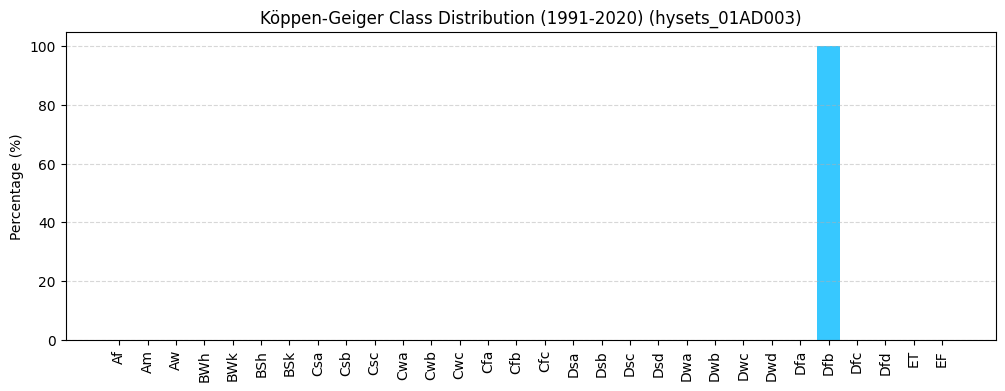

In [7]:
# Run Köppen-Geiger analysis for the catchment
# Saves map, histogram, and table to path_output/koppen_geiger/
save_dir = Path(settings["figure_output"])

df_percent, top_df = analyse_koppen_geiger(
    path_to_file=settings["koppen_raster_path"],
    shapefiles=shapefiles,
    koppen_description=KOPPEN_DESCRIPTION,
    plot_map=True,
    plot_hist=True,
    generate_table=True,
    save_dir=save_dir,
    show_plot=True,
)

In [8]:
# Extract the catchment column, drop zero-coverage classes, sort by percentage descending
catchment_col = settings["caravan_id"]
catchment_percent = df_percent[catchment_col].copy()
# catchment_percent = catchment_percent[catchment_percent > 0].sort_values(ascending=False)

result = pd.DataFrame({
    "Climate class": catchment_percent.index,
    "Description": [KOPPEN_DESCRIPTION.get(c, "") for c in catchment_percent.index],
    "Coverage (%)": catchment_percent.values.round(2),
})

print(f"Köppen-Geiger climate classes for {settings['caravan_id']}:")
display(result)

# Write to results.json (same directory as settings.json)
koppen_dict = {
    row["Climate class"]: float(row["Coverage (%)"]) 
    for _, row in result.iterrows()
}
results_path = Path(settings["results_path"])
results = json.loads(results_path.read_text()) if results_path.exists() else {}
results["koppen_geiger"] = koppen_dict
results_path.write_text(json.dumps(results, indent=4))
print(f"Köppen-Geiger data written to {results_path}")

Köppen-Geiger climate classes for hysets_01AD003:

,Climate class,Description,Coverage (%)
0,Af,Tropical rainforest,0.0
1,Am,Tropical monsoon,0.0
2,Aw,Tropical savanna,0.0
3,BWh,Hot desert,0.0
4,BWk,Cold desert,0.0
5,BSh,Hot steppe,0.0
6,BSk,Cold steppe,0.0
7,Csa,"Mediterranean, hot summer",0.0
8,Csb,"Mediterranean, warm summer",0.0
9,Csc,"Mediterranean, cold summer",0.0


Köppen-Geiger data written to regions/canada/hysets_01AD003/results.json

In [9]:
print(koppen_dict)

{
    'Af': 0.0,
    'Am': 0.0,
    'Aw': 0.0,
    'BWh': 0.0,
    'BWk': 0.0,
    'BSh': 0.0,
    'BSk': 0.0,
    'Csa': 0.0,
    'Csb': 0.0,
    'Csc': 0.0,
    'Cwa': 0.0,
    'Cwb': 0.0,
    'Cwc': 0.0,
    'Cfa': 0.0,
    'Cfb': 0.0,
    'Cfc': 0.0,
    'Dsa': 0.0,
    'Dsb': 0.0,
    'Dsc': 0.0,
    'Dsd': 0.0,
    'Dwa': 0.0,
    'Dwb': 0.0,
    'Dwc': 0.0,
    'Dwd': 0.0,
    'Dfa': 0.0,
    'Dfb': 100.0,
    'Dfc': 0.0,
    'Dfd': 0.0,
    'ET': 0.0,
    'EF': 0.0
}